In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# ----------------------------------------
# Load Engineered Dataset
# ----------------------------------------

df = pd.read_csv("nba_features_with_team_context.csv")

# Parse dates
df["GameDate"] = pd.to_datetime(df["GameDate"])

# ----------------------------------------
# Split Train (pre-2024) and Test (2024–2025 season)
# ----------------------------------------

cutoff_date = pd.to_datetime("2024-10-01")

train_df = df[df["GameDate"] < cutoff_date]
test_df = df[df["GameDate"] >= cutoff_date]

print(f"Train size: {len(train_df)} games")
print(f"Test size: {len(test_df)} games")

# ----------------------------------------
# Prepare Features and Target
# ----------------------------------------

X_train = train_df.drop(columns=["TotalPoints", "GameDate"])
y_train = train_df["TotalPoints"]

X_test = test_df.drop(columns=["TotalPoints", "GameDate"])
y_test = test_df["TotalPoints"]

# Handle missing values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # fill test with training means!

# ----------------------------------------
# Scale Features
# ----------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------
# Define Models
# ----------------------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

# ----------------------------------------
# Train and Evaluate Each Model
# ----------------------------------------

results = []
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

    predictions[name] = y_pred  # store predictions separately

# ----------------------------------------
# Display Results
# ----------------------------------------

results_df = pd.DataFrame(results)
print("\nFinal Model Evaluation on 2024–2025 Season:")
print(results_df)

# Save to CSV
results_df.to_csv("final_model_results_2024_2025.csv", index=False)

# ----------------------------------------
# Save Predictions for Each Model
# ----------------------------------------

for model_name, preds in predictions.items():
    test_results = test_df.copy()
    test_results[f"{model_name}_Predicted_TotalPoints"] = preds
    save_filename = model_name.replace(" ", "_").lower() + "_predictions_2024_2025.csv"
    test_results.to_csv(save_filename, index=False)
    print(f"Saved {model_name} predictions to {save_filename}")


Train size: 10749 games
Test size: 1225 games
Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...
Training Gradient Boosting...

🎯 Final Model Evaluation on 2024–2025 Season:
               Model    MAE   RMSE  R2 Score
0  Linear Regression  15.09  18.98    0.0805
1   Ridge Regression  15.06  18.95    0.0839
2   Lasso Regression  15.04  18.93    0.0853
3      Random Forest  15.55  19.50    0.0293
4  Gradient Boosting  15.17  19.05    0.0737
Saved Linear Regression predictions to linear_regression_predictions_2024_2025.csv
Saved Ridge Regression predictions to ridge_regression_predictions_2024_2025.csv
Saved Lasso Regression predictions to lasso_regression_predictions_2024_2025.csv
Saved Random Forest predictions to random_forest_predictions_2024_2025.csv
Saved Gradient Boosting predictions to gradient_boosting_predictions_2024_2025.csv


In [13]:
import pandas as pd

df = pd.read_csv("lasso_regression_predictions_2024_2025.csv")

# Step 1: Extract HomeTeam and AwayTeam from one-hot columns
home_team_cols = [col for col in df.columns if col.startswith("HomeTeam_")]
away_team_cols = [col for col in df.columns if col.startswith("AwayTeam_")]

# For each row, find which team has the "1" for Home and Away
df["HomeTeam"] = df[home_team_cols].idxmax(axis=1).str.replace("HomeTeam_", "")
df["AwayTeam"] = df[away_team_cols].idxmax(axis=1).str.replace("AwayTeam_", "")

# Step 2: Prepare a nice table
sample = df[[
    "GameDate", "HomeTeam", "AwayTeam", "TotalPoints", "Lasso Regression_Predicted_TotalPoints"
]].copy()

# Clean column names
sample = sample.rename(columns={
    "TotalPoints": "Actual_TotalPoints",
    "Lasso Regression_Predicted_TotalPoints": "Predicted_TotalPoints"
})

# Round predicted total points
sample["Predicted_TotalPoints"] = sample["Predicted_TotalPoints"].round(1)

# Optional: Pick first 10 games or a random sample
sample_table = sample.sample(10)

# Display
print("\nSample Model Predictions for Report:")
print(sample_table)

# Save to CSV if needed
sample_table.to_csv("sample_lasso_predictions_for_report.csv", index=False)



🎯 Sample Model Predictions for Report:
        GameDate                HomeTeam                AwayTeam  \
20    2025-01-15           Chicago Bulls           Atlanta Hawks   
913   2024-12-30  Portland Trail Blazers      Philadelphia 76ers   
648   2025-03-17         New York Knicks              Miami Heat   
52    2024-12-15      Washington Wizards          Boston Celtics   
759   2025-02-05          Denver Nuggets    New Orleans Pelicans   
124   2024-10-25           Atlanta Hawks       Charlotte Hornets   
595   2025-01-27         New York Knicks       Memphis Grizzlies   
249   2024-11-12   Golden State Warriors        Dallas Mavericks   
1028  2024-11-22             LA Clippers        Sacramento Kings   
702   2024-11-24          Boston Celtics  Minnesota Timberwolves   

      Actual_TotalPoints  Predicted_TotalPoints  
20                   204                  238.6  
913                  228                  220.5  
648                  211                  207.2  
52         

In [9]:
lasso_preds_df = pd.read_csv("lasso_regression_predictions_2024_2025.csv")
lasso_preds_df.columns

Index(['GameDate', 'Avg_Pace', 'Pace_Diff', 'OffRating_Diff', 'DefRating_Diff',
       'NetRating_Diff', 'Rest_Days_Diff', 'BackToBack_Sum',
       'Avg_Rolling_Pace_5g', 'Pace_Diff_Rolling_5g',
       'Rolling_OffRating_Diff_5g', 'Rolling_DefRating_Diff_5g',
       'Avg_Rolling_Pace_7g', 'Pace_Diff_Rolling_7g',
       'Rolling_OffRating_Diff_7g', 'Rolling_DefRating_Diff_7g',
       'Avg_Rolling_Pace_10g', 'Pace_Diff_Rolling_10g',
       'Rolling_OffRating_Diff_10g', 'Rolling_DefRating_Diff_10g',
       'TotalPoints', 'HomeTeam_Atlanta Hawks', 'HomeTeam_Boston Celtics',
       'HomeTeam_Brooklyn Nets', 'HomeTeam_Charlotte Hornets',
       'HomeTeam_Chicago Bulls', 'HomeTeam_Cleveland Cavaliers',
       'HomeTeam_Dallas Mavericks', 'HomeTeam_Denver Nuggets',
       'HomeTeam_Detroit Pistons', 'HomeTeam_Golden State Warriors',
       'HomeTeam_Houston Rockets', 'HomeTeam_Indiana Pacers',
       'HomeTeam_LA Clippers', 'HomeTeam_Los Angeles Lakers',
       'HomeTeam_Memphis Grizzlies', 'H

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("nba_features_with_team_context.csv")

# Prepare train/test split
df["GameDate"] = pd.to_datetime(df["GameDate"])
cutoff_date = pd.to_datetime("2024-10-01")

train_df = df[df["GameDate"] < cutoff_date]
test_df = df[df["GameDate"] >= cutoff_date]

X_train = train_df.drop(columns=["TotalPoints", "GameDate"])
y_train = train_df["TotalPoints"]
X_test = test_df.drop(columns=["TotalPoints", "GameDate"])
y_test = test_df["TotalPoints"]

# Handle missing values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

# Standardize data for Ridge and Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Models to Tune ----

# Ridge
ridge = Ridge()
ridge_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_absolute_error')
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_

# Lasso
lasso = Lasso(max_iter=5000)
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_absolute_error')
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, 20]}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_mean_absolute_error')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb_params = {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='neg_mean_absolute_error')
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

# ---- Evaluation ----
models = {
    "Ridge Regression (Tuned)": best_ridge,
    "Lasso Regression (Tuned)": best_lasso,
    "Random Forest (Tuned)": best_rf,
    "Gradient Boosting (Tuned)": best_gb,
}

results = []
for name, model in models.items():
    if "Ridge" in name or "Lasso" in name:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test
    
    y_pred_train = model.predict(Xtr)
    y_pred_test = model.predict(Xte)
    
    results.append({
        "Model": name,
        "MAE_Train": mean_absolute_error(y_train, y_pred_train),
        "MAE_Test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_Train": r2_score(y_train, y_pred_train),
        "R2_Test": r2_score(y_test, y_pred_test),
    })

# Final results
results_df = pd.DataFrame(results)
print("\nTuned Model Results:")
print(results_df)
results_df.to_csv("tuned_model_evaluation.csv", index=False)


C:\Users\Theo\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.051e+03, tolerance: 3.870e+02
  model = cd_fast.enet_coordinate_descent(



🎯 Tuned Model Results:
                       Model  MAE_Train   MAE_Test  RMSE_Train  RMSE_Test  \
0   Ridge Regression (Tuned)  15.064945  15.055720   19.022962  18.941537   
1   Lasso Regression (Tuned)  15.075648  15.012563   19.043238  18.894643   
2      Random Forest (Tuned)  14.791810  15.190538   18.678185  19.056405   
3  Gradient Boosting (Tuned)  14.516506  15.168390   18.341004  19.050157   

   R2_Train   R2_Test  
0  0.210912  0.084261  
1  0.209229  0.088789  
2  0.239256  0.073120  
3  0.266474  0.073728  


In [20]:
# Lasso Model Feature Analysis

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lasso.coef_
})

# Keep only non-zero coefficients
important_features = coef_df[coef_df["Coefficient"].abs() > 0.001]  # adjust threshold if needed
important_features = important_features.sort_values(by="Coefficient", key=np.abs, ascending=False)

print(important_features)


                            Feature  Coefficient
0                          Avg_Pace     9.218113
64              AwayTeam_Miami Heat    -0.796544
33       HomeTeam_Memphis Grizzlies    -0.731028
26          HomeTeam_Denver Nuggets     0.676602
70           AwayTeam_Orlando Magic    -0.637549
44        HomeTeam_Sacramento Kings     0.579115
13        Rolling_OffRating_Diff_7g     0.561324
43  HomeTeam_Portland Trail Blazers     0.556444
66  AwayTeam_Minnesota Timberwolves     0.538655
19           HomeTeam_Atlanta Hawks     0.488274
40           HomeTeam_Orlando Magic    -0.477260
48      HomeTeam_Washington Wizards     0.423089
32      HomeTeam_Los Angeles Lakers    -0.398851
24     HomeTeam_Cleveland Cavaliers     0.393357
69   AwayTeam_Oklahoma City Thunder    -0.381948
63       AwayTeam_Memphis Grizzlies    -0.311750
51           AwayTeam_Brooklyn Nets     0.285686
50          AwayTeam_Boston Celtics    -0.276492
71      AwayTeam_Philadelphia 76ers    -0.244207
3                   

In [24]:
# Filter out any feature that starts with "HomeTeam_" or "AwayTeam_"
non_team_features = important_features[
    ~important_features["Feature"].str.startswith(("HomeTeam_", "AwayTeam_"))
]

# Sort by absolute coefficient size
non_team_features = non_team_features.sort_values(by="Coefficient", key=np.abs, ascending=False)

print(non_team_features)

                       Feature  Coefficient
0                     Avg_Pace     9.218113
13   Rolling_OffRating_Diff_7g     0.561324
3               DefRating_Diff     0.230970
17  Rolling_OffRating_Diff_10g     0.100056
1                    Pace_Diff    -0.068332
10   Rolling_DefRating_Diff_5g     0.067426
6               BackToBack_Sum    -0.003850


In [28]:
# best lasso model predictions

df = pd.read_csv("nba_features_with_team_context.csv")

# Parse dates
df["GameDate"] = pd.to_datetime(df["GameDate"])

# Filter for 2024–2025 Regular Season games
test_df = df[df["GameDate"] >= pd.to_datetime("2024-10-01")]

# Separate features and target
X_test = test_df.drop(columns=["TotalPoints", "GameDate"])
y_test = test_df["TotalPoints"]

# Handle missing values
X_test = X_test.fillna(X_test.mean())

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  # Simple re-fit for this test block

# Predict using your best tuned Lasso model
y_pred = best_lasso.predict(X_test_scaled)

# Build comparison table
predictions_df = pd.DataFrame({
    "GameDate": test_df["GameDate"].values,
    "HomeTeam": test_df.filter(like="HomeTeam_").idxmax(axis=1).str.replace("HomeTeam_", ""),
    "AwayTeam": test_df.filter(like="AwayTeam_").idxmax(axis=1).str.replace("AwayTeam_", ""),
    "Actual_TotalPoints": y_test.values,
    "Predicted_TotalPoints": y_pred.round(1)
})

# Preview top 10
print(predictions_df.sample(10))

# Save to CSV
predictions_df.to_csv("lasso_predictions_vs_actuals_2024_2025.csv", index=False)


        GameDate                HomeTeam                AwayTeam  \
1562  2024-12-05         New York Knicks       Charlotte Hornets   
2765  2025-01-23   Oklahoma City Thunder        Dallas Mavericks   
7138  2024-11-21         Toronto Raptors  Minnesota Timberwolves   
11952 2025-01-23             LA Clippers      Washington Wizards   
3180  2025-03-21  Portland Trail Blazers          Denver Nuggets   
7159  2025-02-24   Oklahoma City Thunder  Minnesota Timberwolves   
2763  2025-01-15    New Orleans Pelicans        Dallas Mavericks   
3160  2024-12-30               Utah Jazz          Denver Nuggets   
11955 2025-02-01  Minnesota Timberwolves      Washington Wizards   
3181  2025-03-23         Houston Rockets          Denver Nuggets   

       Actual_TotalPoints  Predicted_TotalPoints  
1562                  226                  209.3  
2765                  236                  226.1  
7138                  215                  220.7  
11952                 203                  221.

In [34]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = root_mean_squared_error(y_test, y_pred)

print(f"2024–2025 Season MAE: {mae_test:.2f}")
print(f"2024–2025 Season RMSE: {rmse_test:.2f}")


2024–2025 Season MAE: 15.96
2024–2025 Season RMSE: 20.16


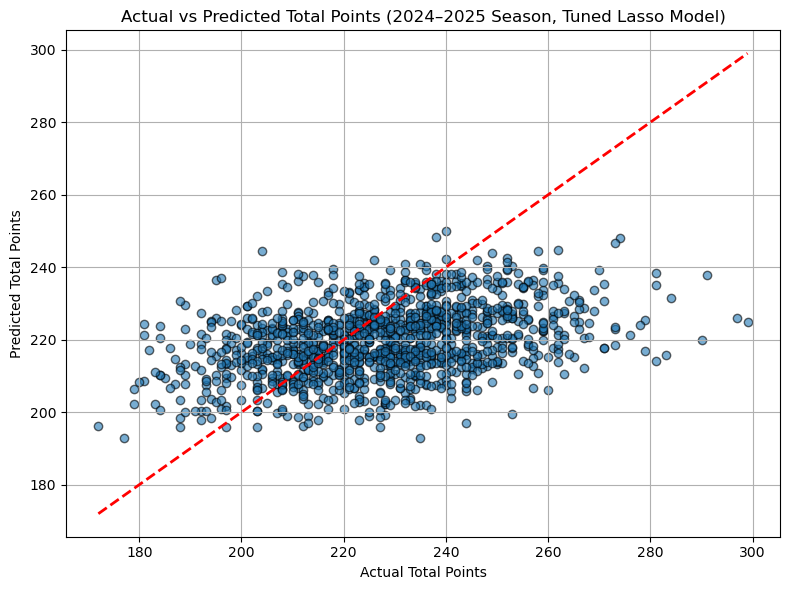

In [38]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Total Points")
plt.ylabel("Predicted Total Points")
plt.title("Actual vs Predicted Total Points (2024–2025 Season, Tuned Lasso Model)")
plt.grid(True)
plt.tight_layout()

plt.savefig("actual_vs_predicted_totalpoints_lasso.png", dpi=300)

plt.show()

In [40]:
import numpy as np

# Assuming you have:
# y_test = actual total points (array or Series)
# y_pred = predicted total points (from tuned Lasso model)

# Define your tolerance
for tol in [5, 7.5, 10, 12.5, 15]:
    correct_pct = (np.abs(y_test - y_pred) <= tol).mean() * 100
    print(f"Within ±{tol} points: {correct_pct:.2f}% correct")


Within ±5 points: 20.57% correct
Within ±7.5 points: 29.47% correct
Within ±10 points: 38.12% correct
Within ±12.5 points: 46.69% correct
Within ±15 points: 54.45% correct


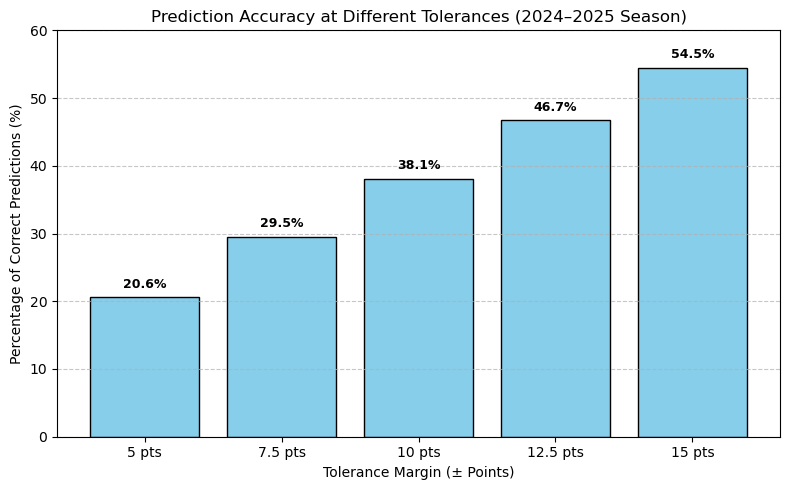

In [44]:
import matplotlib.pyplot as plt

# Your computed percentages
tolerances = [5, 7.5, 10, 12.5, 15]
accuracies = [20.57, 29.47, 38.12, 46.69, 54.45]

# Create the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar([str(tol) + " pts" for tol in tolerances], accuracies, color="skyblue", edgecolor="k")
plt.xlabel("Tolerance Margin (± Points)")
plt.ylabel("Percentage of Correct Predictions (%)")
plt.title("Prediction Accuracy at Different Tolerances (2024–2025 Season)")
plt.ylim(0, 60)  # Optional adjust if needed
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add percentage labels on top of each bar
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,  # slightly above the bar
        f"{acc:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Save the figure
plt.tight_layout()
plt.savefig("prediction_accuracy_by_tolerance_labeled.png", dpi=300)

# Show the plot
plt.show()


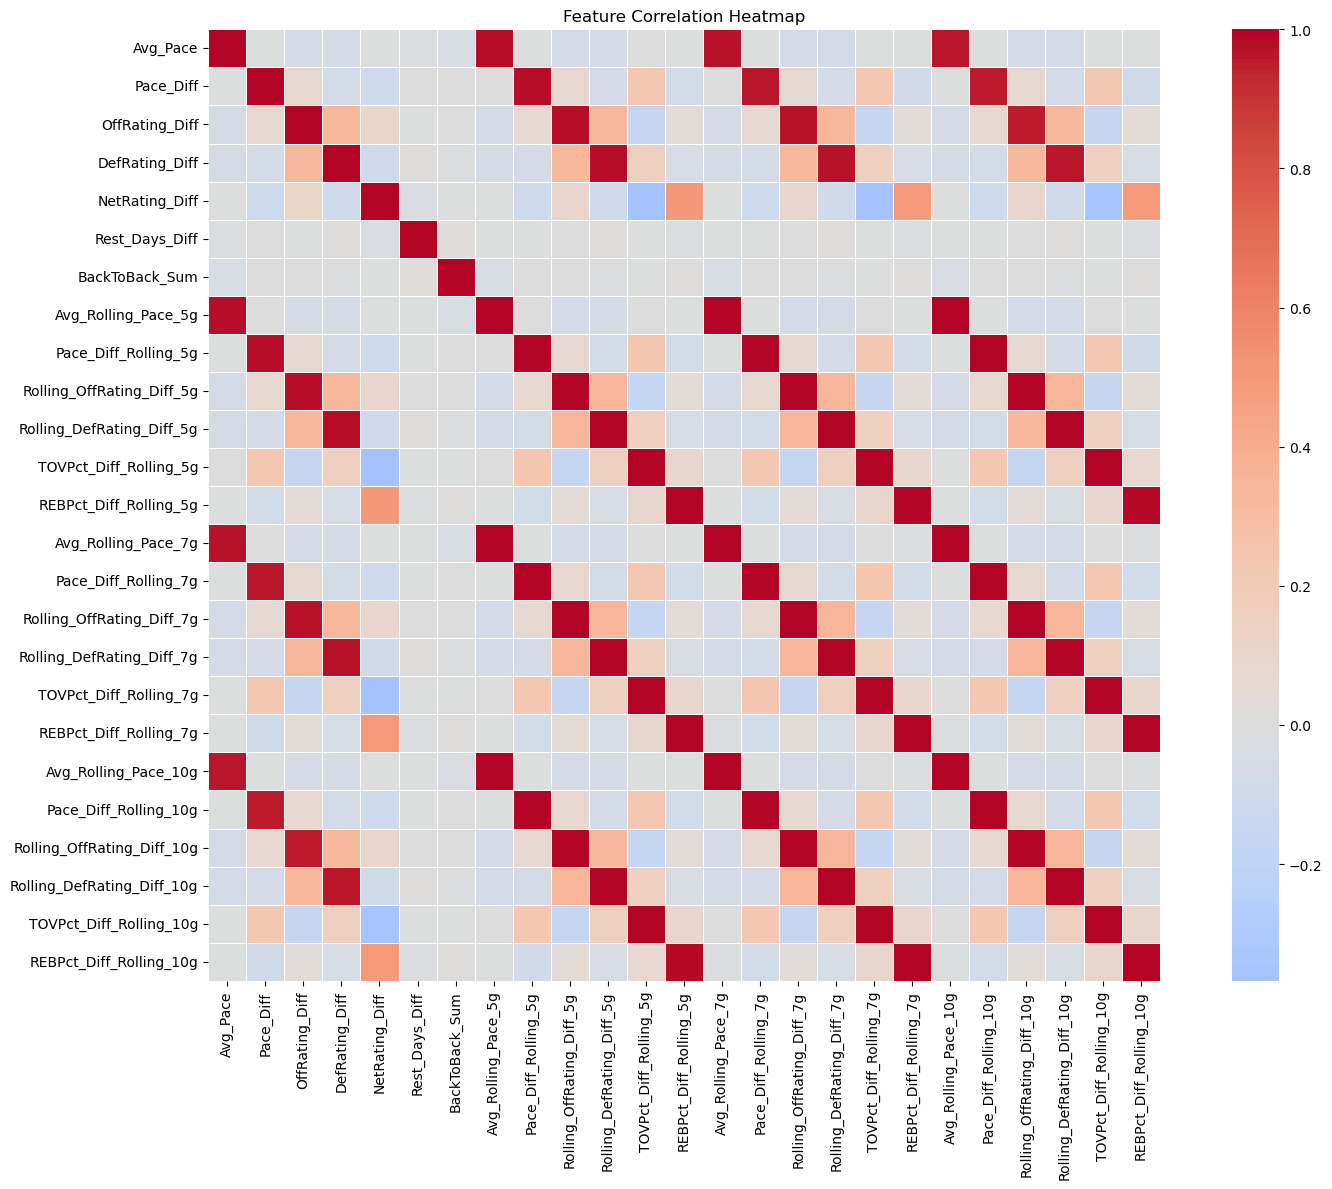

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your feature dataset
df = pd.read_csv("nba_features_for_modeling.csv")

# Drop TotalPoints and any non-feature columns if needed
features_only = df.drop(columns=["TotalPoints", "GameDate"])  # drop target and non-numeric fields

# Compute Pearson correlation matrix
corr_matrix = features_only.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5, annot=False, fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

# Save figure
plt.savefig("feature_correlation_heatmap.png", dpi=300)
plt.show()
